
# Loan Approval Prediction

## Problem Statement

Banks need to decide whether a loan applicant should be **approved or rejected** based on their financial information.

You are given a dataset containing details such as:

* Applicant income
* Loan amount
* Credit history
* Education
* Marital status

Build a **Logistic Regression model** to predict whether the loan application should be **Approved (1) or Rejected (0)**.

Students should:

1. Load the dataset
2. Handle categorical variables
3. Train a Logistic Regression model
4. Evaluate the model performance
5. Predict approval for new applicants

---

## Dataset

Kaggle Dataset:
[https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)

Important Columns:

| Feature         | Description             |
| --------------- | ----------------------- |
| ApplicantIncome | Income of applicant     |
| LoanAmount      | Loan requested          |
| Credit_History  | Credit score history    |
| Education       | Graduate / Not Graduate |
| Loan_Status     | Target variable         |

Target Variable:

```
Loan_Status
```

Where:

* **Y = Approved**
* **N = Rejected**


In [28]:
#Step 1: Import Libraries

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [11]:
#Step 2: Load Dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files: /kaggle/input/loan-prediction-problem-dataset


In [12]:
# Load the CSV into a DataFrame
files = os.listdir(path)
print("Available files:", files)

# Find the training file (whichever contains 'train' in the name)
train_file = [f for f in files if 'train' in f.lower()]

if train_file:
    df = pd.read_csv(os.path.join(path, train_file[0]))
else:
    # Fallback: just print files and pick manually
    print("No train file found. Files available:", files)

df.head()

Available files: ['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
# Step 3: Handle Missing Values
print("Missing values before:\n", df.isnull().sum())

# Numerical columns → fill with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

# Categorical columns → fill with mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

print("\nMissing values after:\n", df.isnull().sum())

Missing values before:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Missing values after:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [14]:
#Step 4: Convert Categorical Variables

encoder = LabelEncoder()

df['Education'] = encoder.fit_transform(df['Education'])
df['Married'] = encoder.fit_transform(df['Married'])
df['Loan_Status'] = encoder.fit_transform(df['Loan_Status'])

In [15]:
#Step 5: Select Features

X = df[['ApplicantIncome','LoanAmount','Credit_History','Education']]
y = df['Loan_Status']

In [16]:
#Step 6: Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
# Step 7: Scale the Features ← Add this before Step 6

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only, not fit_transform

In [19]:
# Step 8: Train Model — increase max_iter
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
#Step 9: Prediction

y_pred = model.predict(X_test)

In [21]:
#Step 10: Model Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.7886178861788617


In [22]:
#Step 9: Evaluate Model - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18 25]
 [ 1 79]]


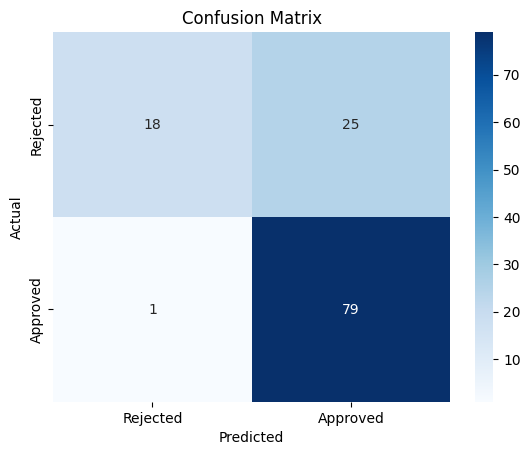

In [26]:
#Step 11: Confusion Matrix Visualization

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],  # ← was 'Fail', 'Pass'
            yticklabels=['Rejected', 'Approved'])   # ← was 'Fail', 'Pass'
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Step 12: Predict for a New Applicant
# Features used: ['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Education']
#                      50000          200              1                 1 (Graduate)

new_applicant = [[50000, 200, 1, 1]]  # 4 features to match training data
new_applicant_scaled = scaler.transform(new_applicant)
prediction = model.predict(new_applicant_scaled)

if prediction[0] == 1:
    print("Loan Application: APPROVED ✅")
else:
    print("Loan Application: REJECTED ❌")

Loan Application: APPROVED ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
